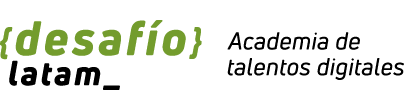

# <center><font color="green">Estadística inferencial</font></center>

## <font color="green">Prueba de hipótesis</font>

Python nos permite determinar fácilmente valores críticos e implementar modelos para pruebas de hipótesis. Veremos a continuación algunos de estos procedimientos para aplicar pruebas de hipótesis sobre una base de datos considerándola una muestra de una población total.


In [2]:
import pandas as pd
import seaborn as sns
import scipy.stats as st
import numpy as np

# Cargar el conjunto de datos de pingüinos desde Seaborn
pinguins = sns.load_dataset("penguins")


In [3]:
pinguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Utilizaremos los datos sobre diversas medidas corporrales de especies de pingüinos; en particular nos fijaremos en los pingüinos de especie Adelia y su masa corporal.

In [4]:
# Filtrar los dats para obtener solo los pesos de los pingüinos Adelia
adelia = pinguins[pinguins["species"] == "Adelie"]["body_mass_g"]
# Eliminar filas con valores faltantes en los datos de Adelia
adelia = adelia.dropna()


In [5]:
adelia

0      3750.0
1      3800.0
2      3250.0
4      3450.0
5      3650.0
        ...  
147    3475.0
148    3450.0
149    3750.0
150    3700.0
151    4000.0
Name: body_mass_g, Length: 151, dtype: float64

Calcularemos, primero, el promedio de las masas de estos pingüinos. Esto nos permitirá poner a prueba algunas hipótesis.

In [6]:
media=np.mean(adelia)
print(media)

3700.662251655629


In [7]:
adelia.mean()

3700.662251655629

In [8]:
(50/media)*100

1.351109520400859

Vamos a ver ahora qué se obtiene al realizar pruebas t con diferentes medias hipotéticas, para la muestra de pingüinos adelia.

In [9]:
medias = [media - 50, media-1, media, media+50, media+3000]

for mu in medias:
  # Realizar una prueba de hipótesis para verificar si el peso de Adelia es igual a mu
  t_stat, p_value = st.ttest_1samp(adelia, mu)
  print(f"Media {mu}")
  print(f"Valor t: {t_stat}")
  print(f"Valor p: {p_value}\n")


Media 3650.662251655629
Valor t: 1.3398510087346298
Valor p: 0.18232003477577144

Media 3699.662251655629
Valor t: 0.0267970201746926
Valor p: 0.9786572476230542

Media 3700.662251655629
Valor t: 0.0
Valor p: 1.0

Media 3750.662251655629
Valor t: -1.3398510087346298
Valor p: 0.18232003477577144

Media 6700.662251655629
Valor t: -80.3910605240778
Valor p: 3.136232388747058e-125



El valor de t corresponde a la diferencia entre la media muestral $\overline{x}$ y la media hipotética $\mu$, normalizada dividiendo por la desviación estándar. Dado que la distribución de probabilidad es simétrica, los valores correspondientes a "media-50" y "media+50" presentan valores t iguales en valor absoluto, y valores p iguales. Observamos también que el valor de t aumenta en valor absoluto mientras mayor sea la distancia de la media "hipotética" con la "media muestral", y cuando esto ocurre el valor de p disminuye cada vez más acercándose a cero.


¿Cómo interpretamos esto? Mientras mayor sea la diferencia entre la media hipotética y la media muestral, es cada vez menos probable que la media hipotética sea, efectivamente, la media de la población. ¿Qué probabilidad estamos dispuestos a aceptar? Vamos a **rechazar** la hipótesis nula si el valor de p es menor que el nivel de significancia escogido. Así, en nuestro ejemplo, si asumimos un nivel de significancia igual a 0.1, por ejemplo, tendremos que:

*  No podemos rechazar la hipótesis de que la media poblacional sea "media-50", ya que p = 0.18, que es mayor que 0.1
*  Si podemos rechazar la hipótesis de que la media poblacional sea "media+3000", ya que p = 3.136232388747058e-125, que es menor que 0.1

Podemos observar que nuestra hipótesis alternativa sería "de dos colas", ya que estamos afirmando que la media sería diferente a la supuesta pero no indicamos en qué sentido. Python nos permite considerar esto agregando un parámetro a la función

In [13]:
t_stat, p_value = st.ttest_1samp(adelia, media-1000, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media-100, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media-1, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")


t_stat, p_value = st.ttest_1samp(adelia, media+1, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media+10, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media+100, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media+1000, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")


Valor t: 26.797020174692598
Valor p: 2.3312641185104634e-59

Valor t: 2.6797020174692596
Valor p: 0.004096100942733048

Valor t: 0.0267970201746926
Valor p: 0.4893286238115271

Valor t: -0.0267970201746926
Valor p: 0.5106713761884729

Valor t: -0.267970201746926
Valor p: 0.6054548015632181

Valor t: -2.6797020174692596
Valor p: 0.995903899057267

Valor t: -26.797020174692598
Valor p: 1.0



"Alternative='greater' indica que nuestra hipótesis alternativa es que la media de la población es mayor que la que estamos suponiendo. Si consideramos un valor **muy menor que** la media poblacional como media hipotética, es muy probable que debamos rechazar dicha hipótesis nula a cambio de la alternativa, que postula que la media es **mayor** que la hipotética. Naturalmente, mientras más nos vayamos acercando a la media real el valor de p irá aumentando. Notarenos que, aun si nuestra media muestral propuesta es menor que la muestral, no podemos descartar la hipótesis nula pues sigue teniendo una alta probabilidad.

¿Qué ocurre cuando comenzamos a tomar valores **mayores que** nuestra media muestral? El valor de p irá aumentando (hasta hacerse 1, o muy cerca de 1). En el último caso, en que hemos tomado una media hipotética igual a "media + 1000", obtenemos un valor de p igual a 1 que nos indicaría... **¡qué no podemos rechazar la hipótesis!** ¿Significa que debemos aceptar, realmente, que esta es la media? En realidad no. Lo que estamos afirmando que la hipótesis alternativa (que la media poblacional sea **mayor que "media+1000"**) es muuuucho menos probable.

Tenemos otras posibilidades, además: "alternative=less" (menor que) y "alternative=two-side" (dos lados) que es la opción por defecto.

In [16]:
t_stat, p_value = st.ttest_1samp(adelia, media-1000) #, alternative='greater')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

t_stat, p_value = st.ttest_1samp(adelia, media-1000, alternative='less')
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

Valor t: 26.797020174692598
Valor p: 4.662528237020927e-59

Valor t: 26.797020174692598
Valor p: 1.0



<center><strong>¡Ahora podemos regresar a nuestra presentación!</center></strong>

## <font color="green">Infiriendo sobre la media - Intervalos de confianza</font>

Considerando la misma muestra anterior, podemos construir un intervalo de confianza para estimar la media poblacional. Utilizaremos un nivel de confianza del 95%.

### Con distribución t



In [17]:
# crear un intervalo de confianza del 95% para el peso medio de la población
st.t.interval(0.95, df = len (adelia) -1, loc = media, scale = st.sem(adelia))

(3626.9262422782513, 3774.3982610330067)

In [18]:
media

3700.662251655629

In [19]:
media - 3626.9262422782513


73.73600937737774

In [20]:
3774.3982610330067 - media

73.73600937737774

In [21]:
print(f" extremos  ==> {adelia.min()} - {adelia.max()}")

 extremos  ==> 2850.0 - 4775.0


In [22]:
3626.9262422782513- adelia.min()

776.9262422782513

In [23]:
adelia.max()- 3774.3982610330067

1000.6017389669933

Podemos identificar aquí los siguientes parámetros:

*  Confidence=0.95 (1-alpha): corresponde al nivel de confianza. Obserza que se da directamente.

*  df=len(data)-1: corresponde al número de grados de libertad para la distribución t. Se calcula restando 1 al número de observaciones en la muestra.

*  loc=media: utilizamos la media de la muestra como estimador para nuestro intervalo de confianza.

*  scale=st.sem(adelia): Se calcula el error estándar de la media (SEM) de la muestra de datos utilizando st.sem(adelia). El error estándar de la media es una medida de la variabilidad de la media muestral y se utiliza para calcular la amplitud del intervalo de confianza.

Calculando el error y definiendo la confiabilidad podemos escribir una afirmación en lenguaje natural:

In [24]:
confianza=0.95
# crear un intervalo de confianza del 95% para el peso medio de la población
a,b=st.t.interval (confianza, df = len (adelia) -1, loc = media, scale = st.sem (adelia))
error=round(b-media,2)
media_estimada=round(media,2)
conf=confianza*100
print(f'La media poblacional es {media_estimada}, con un margen de error de {error} y confiabilidad del {conf}%')

La media poblacional es 3700.66, con un margen de error de 73.74 y confiabilidad del 95.0%


In [25]:
adelia.size

151

In [26]:
pinguins.dropna().size

2331

In [27]:
(adelia.size/pinguins.dropna().size)*100

6.477906477906478

### Con distribución normal




In [28]:
# crear un intervalo de confianza del 95% para el peso medio de la población
a,b = st.norm.interval(confianza, loc=media, scale=np.std(adelia))
print(f"diferencia intervalo media {b-media}")
print(a,b)

diferencia intervalo media 895.7920778238886
2804.8701738317404 4596.454329479518


## <font color="green">Infiriendo sobre la proporción</font>

Consideraremos ahora los datos para inferir sobre la proporción de pingüinos machos sobre el total de la población

In [29]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# Cargar el conjunto de datos de pingüinos desde Seaborn
pinguins = sns.load_dataset("penguins")

# Filtrar los datos para obtener solo los pingüinos Adelia
adelia = pinguins[pinguins["species"] == "Adelie"]

# Tamaño de la muestra
n = len(adelia)

# Contar la cantidad de machos en la muestra
num_machos = adelia[adelia["sex"] == "Male"]["sex"].count()

# Proporción muestral de machos en la muestra
proporcion_muestral = num_machos / n

# Nivel de confianza (por ejemplo, 95%)
confianza = 0.95

# Calcular el intervalo de confianza utilizando statsmodels
intervalo_confianza = sm.stats.proportion_confint(num_machos, n, alpha=1 - confianza)

# Imprimir el resultado
print(f"Intervalo de confianza del {confianza * 100}% para la proporción de machos en la población de pingüinos Adelia:")
print(f"({intervalo_confianza[0]}, {intervalo_confianza[1]})")



Intervalo de confianza del 95.0% para la proporción de machos en la población de pingüinos Adelia:
(0.4008380735291567, 0.559688242260317)


In [30]:
num_machos/len(adelia)

0.48026315789473684

<center><strong>¡Ahora podemos regresar a nuestra presentación!</center></strong>

## <font color="green">Prueba de hipótesis para muestras independientes</font>

Compararemos ahora la diferencia en el peso corporal entre las especies de pingüinos "Adelie" y "Chinstrap". La hipótesis nula (H0) sería que no hay diferencia significativa en el peso corporal entre las especies, y la hipótesis alternativa (H1) es que sí hay una diferencia significativa.

In [31]:
import pandas as pd
import seaborn as sns
from scipy import stats

# Cargar el conjunto de datos de pingüinos desde Seaborn
pinguins = sns.load_dataset("penguins")

# Filtrar los datos para obtener los pesos corporales de las especies "Adelie" y "Chinstrap"
adelie = pinguins[pinguins["species"] == "Adelie"]["body_mass_g"]
chinstrap = pinguins[pinguins["species"] == "Chinstrap"]["body_mass_g"]

# Eliminar filas con valores nulos en los datos de peso corporal
adelie = adelie.dropna()
chinstrap = chinstrap.dropna()

# Realizar una prueba de hipótesis (prueba t de muestras independientes)
t_stat, p_value = stats.ttest_ind(adelie, chinstrap, equal_var=False)

# Nivel de significancia (alfa)
alpha = 0.05

# Comprobar si el valor p es menor que alfa para rechazar la hipótesis nula
if p_value < alpha:
    print("Resultado: Se rechaza la hipótesis nula")
else:
    print("Resultado: No se rechaza la hipótesis nula")

# Imprimir el valor t y el valor p
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}")



Resultado: No se rechaza la hipótesis nula
Valor t: -0.5430902472363278
Valor p: 0.5878608159584937


Se acepta la hipotesis nula, pues el p-value es notoriamente mayor a al nivel de signifcancia escogido de 0.05

# DESAFIO

In [32]:
import pandas as pd

In [33]:
df = pd.read_csv('earnings.csv')

In [34]:
df.head()

,height,weight,male,earn,earnk,ethnicity,education,mother_education,father_education,walk,exercise,smokenow,tense,angry,age
0,74,210.0,1,50000.0,50.0,White,16.0,16.0,16.0,3,3,2.0,0.0,0.0,45
1,66,125.0,0,60000.0,60.0,White,16.0,16.0,16.0,6,5,1.0,0.0,0.0,58
2,64,126.0,0,30000.0,30.0,White,16.0,16.0,16.0,8,1,2.0,1.0,1.0,29
3,65,200.0,0,25000.0,25.0,White,17.0,17.0,NaN,8,1,2.0,0.0,0.0,57
4,63,110.0,0,50000.0,50.0,Other,16.0,16.0,16.0,5,6,2.0,0.0,0.0,91


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            1816 non-null   int64  
 1   weight            1789 non-null   float64
 2   male              1816 non-null   int64  
 3   earn              1816 non-null   float64
 4   earnk             1816 non-null   float64
 5   ethnicity         1816 non-null   object 
 6   education         1814 non-null   float64
 7   mother_education  1572 non-null   float64
 8   father_education  1521 non-null   float64
 9   walk              1816 non-null   int64  
 10  exercise          1816 non-null   int64  
 11  smokenow          1815 non-null   float64
 12  tense             1815 non-null   float64
 13  angry             1815 non-null   float64
 14  age               1816 non-null   int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 212.9+ KB


In [36]:
df['earn'].std()

22531.76512330289

In [37]:
import numpy as np

In [38]:
np.std(df['earn'])

22525.560589212157

In [39]:
df['earn'].std(ddof = 0)

22525.560589212157

In [41]:
def proporcion(df, columna, categoria):
    total = df.shape[0]
    subConjunto = df[df[columna] == categoria]
    subTotal = subConjunto.shape[0]
    return subTotal/total

In [42]:
proporcion(df, 'male', 1)

0.3716960352422907

In [43]:
df.shape

(1816, 15)

In [44]:
len(df)

1816

1. **Considerando las variables earn, height y age, vamos a suponer que nuestro dataset fuera una población completa. (Prepara los datos adecuadamente).**

**a. Realiza pruebas con muestras de tamaño n = 25, en cada caso, con niveles de significancia diferentes pero inferiores a 0.1 pero mayores que 0.01, para confirmar o rechazar las siguientes hipótesis considerando las alternativas. Crea para ello una fórmula que reciba los parámetros adecuados y responda "con nivel de confianza del ...%, se acepta la hipótesis nula/alternativa".**

In [45]:
muestra = np.random.choice(df['earn'], 25)
muestra.mean()

14820.0

In [49]:
#realizamos una prueba para earn, 𝐻0: 𝑥 = 20000, 𝐻1: 𝑥 ≠ 20000
import scipy.stats as st

columna = df['earn']
columna = columna.dropna()
significancia = 0.05
confianza = (1-significancia)*100
muestra = np.random.choice(columna, 25)
media = 20000
t_stat, p_value = st.ttest_1samp(columna,media,alternative='two-sided')
if p_value < significancia:
    print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis alternativa (la media es distinta {media})")
else:
    print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis nula (la media es igual a {media})")


print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")
print(f"Media Muestra: {muestra.mean()}\n")


Con nivel de confianza de 95.0% se acepta la hipótesis alternativa (la media es distinta 20000)
Valor t: 2.169892820407049
Valor p: 0.030144315705828477

Media Muestra: 20520.0



In [120]:
round(np.random.uniform(0.01, 0.09),2)

0.08

In [128]:
#creamos nuestra función
def test_hipotesis(columna,media,tipo_cola):
  columna=columna.dropna()
  significancia=round(np.random.uniform(0.01, 0.09),2)
  confianza=100*(1-significancia)
  muestra = np.random.choice(columna, 25)
  t_stat, p_value = stats.ttest_1samp(muestra, media, alternative=tipo_cola)
  if p_value < alpha:
    if tipo_cola=='two-side':
      print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis alternativa (la media es distinta {media})")
    if tipo_cola=='greater':
      print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis alternativa (la media es mayor que {media})")
    if tipo_cola=='less':
      print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis alternativa (la media es menor que {media})")
  else:
    print(f"Con nivel de confianza de {confianza}% se acepta la hipótesis nula (la media es igual a {media})")
  print(f"Valor t: {t_stat}")
  print(f"Valor p: {p_value}")
  print(f"Media Muestra: {muestra.mean()}")
  print(f"Significancia (error a tolerar): {significancia}\n")

In [152]:
#la ejecutamos
test_hipotesis(df['earn'],20000,'two-sided')

Con nivel de confianza de 97.0% se acepta la hipótesis nula (la media es igual a 20000)
Valor t: 0.4661520904871815
Valor p: 0.6453098857556574
Media Muestra: 22040.0
Significancia (error a tolerar): 0.03



In [154]:
#pendiente ==> iterar sobre todos los casos
casos = [
    {'columna': 'earn', 'media_poblacional': 20000, 'tipo_cola': 'two-sided'},
    {'columna': 'earn', 'media_poblacional': 35000, 'tipo_cola': 'two-sided'},
    {'columna': 'earn', 'media_poblacional': 25000, 'tipo_cola': 'greater'},
    {'columna': 'earn', 'media_poblacional': 32000, 'tipo_cola': 'less'},
]

In [155]:
for caso in casos:
   test_hipotesis(df[caso['columna']],caso['media_poblacional'],caso['tipo_cola']) 

Con nivel de confianza de 96.0% se acepta la hipótesis nula (la media es igual a 20000)
Valor t: -0.8478068470839709
Valor p: 0.4049216808556768
Media Muestra: 17468.0
Significancia (error a tolerar): 0.04

Valor t: -5.2264980333984985
Valor p: 2.3443550982201906e-05
Media Muestra: 16216.0
Significancia (error a tolerar): 0.09

Con nivel de confianza de 93.0% se acepta la hipótesis nula (la media es igual a 25000)
Valor t: 0.5252951988870966
Valor p: 0.302098817566459
Media Muestra: 28924.0
Significancia (error a tolerar): 0.07

Con nivel de confianza de 99.0% se acepta la hipótesis nula (la media es igual a 32000)
Valor t: -1.2722826077417926
Valor p: 0.1077309833760263
Media Muestra: 24896.0
Significancia (error a tolerar): 0.01



2. **Crea una función que estime la proporción de hombres en el dataset, considerando
una muestra de 50 individuos, con niveles de significancia de 0,05 y 0,01. Escribe con
palabras tus resultados ejecutar la función e interpreta. Compara con la proporción
real.**

In [156]:
df['male'].value_counts('%')[1]

0.3716960352422907

In [157]:
df.shape

(1816, 15)

In [158]:
def proporcion(df, columna, categoria):
    total = df.shape[0]
    subConjunto = df[df[columna] == categoria]
    subTotal = subConjunto.shape[0]
    return subTotal/total

In [159]:
proporcion(df, 'male', 1)

0.3716960352422907

In [166]:
#ejemplo
import pandas as pd
import seaborn as sns
import statsmodels.api as sm


# Tamaño de la muestra
n = df.shape[0]

# Contar la cantidad de machos en la muestra
num_machos = df[df['male'] == 1]['male'].sum()

# Proporción muestral de machos en la muestra
proporcion_muestral = num_machos / n

# Nivel de confianza (por ejemplo, 95%)
confianza = 0.95

# Calcular el intervalo de confianza utilizando statsmodels
intervalo_confianza = sm.stats.proportion_confint(num_machos, n, alpha=1 - confianza)

# Imprimir el resultado
print(f"Intervalo de confianza del {confianza * 100}% para la proporción de machos en la población hombre:")
print(f"({intervalo_confianza[0]}, {intervalo_confianza[1]})")

Intervalo de confianza del 95.0% para la proporción de machos en la población hombre:
(0.34946963997863645, 0.393922430505945)


In [164]:
proporcion(df, 'male', 1)

0.3716960352422907

3. **Considerando el dataset como una muestra, verifica si el género (male=1 significa ‘hombre”) influye sobre el sueldo “earn” de las personas. Explica y justifica tu procedimiento.**

In [167]:
# Filtrar los datos para obtener los pesos corporales de las especies "Adelie" y "Chinstrap"
males = df[df["male"] == 1]["earn"]
no_males = df[df["male"] == 0]["earn"]

# Eliminar filas con valores nulos en los datos de peso corporal
males = males.dropna()
no_males = no_males.dropna()

# Realizar una prueba de hipótesis (prueba t de muestras independientes)
t_stat, p_value = stats.ttest_ind(males, no_males, equal_var=False)

# Nivel de significancia (alfa)
alpha = 0.05

# Comprobar si el valor p es menor que alfa para rechazar la hipótesis nula
if p_value < alpha:
    print("Resultado: Se rechaza la hipótesis nula")
else:
    print("Resultado: No se rechaza la hipótesis nula")

# Imprimir el valor t y el valor p
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}")

Resultado: Se rechaza la hipótesis nula
Valor t: 11.86459381795286
Valor p: 2.7373648004575493e-30


Se observa que se debe rechazar hipótesis nula en favor de la alternativa y en consecuencia existe una diferencia estadísticamente significativa entre los ingresos de los hombres y las mujeres